# 📊 AWS FinOps Watch: Pipeline Học Máy Đa Lớp Walk-Forward (MLOps)
Dự án Capstone Phase 2 - Task Force 2 (FinOps Watch)

Sổ tay Jupyter này triển khai một **Pipeline Học Máy Đa Lớp hoàn chỉnh với phương pháp Walk-Forward Validation (TimeSeriesSplit)**.

### 🧠 Tại sao chia dữ liệu Walk-Forward lại phù hợp nhất với mô hình Boosting?
Các mô hình Boosting (như XGBoost) là các thuật toán dựa trên cây quyết định. Chúng có những đặc trưng sau:
1. **Không thể ngoại suy xu hướng (Extrapolation)**: Các mô hình cây không thể dự đoán các giá trị nằm ngoài phạm vi đặc trưng mà chúng đã thấy trong tập huấn luyện. Nếu một bất thường loại mới xuất hiện (ví dụ: Lambda debug log runaway **A6** xuất hiện vào cuối tháng 4), mô hình huấn luyện chỉ trên tháng 3 sẽ không thể nhận diện được.
2. **Độ nhạy cao với Covariate Shift**: Xu hướng chi tiêu AWS thay đổi liên tục. Sử dụng mốc thời gian cố định dài ngày khiến mô hình bị lỗi thời.
3. **Walk-Forward Validation (Expanding Window)**: Bằng cách chia dữ liệu thành nhiều Fold tăng dần theo thời gian (Fold 1: Train tháng 3, Val tháng 4; Fold 2: Train tháng 3+4, Val tháng 5), chúng ta mô phỏng chính xác chu kỳ retrain mô hình trong môi trường Production. Việc này giúp mô hình học được các bất thường mới (như A6) trước khi dự đoán tương lai (tháng 5).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import os
import warnings
warnings.filterwarnings('ignore')

# Cấu hình phong cách biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
print("Libraries and dependencies imported successfully!")

Libraries and dependencies imported successfully!


C:\Users\ASUS\OneDrive\Obsidian Vault\XBrain-Phase2\Capstone_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Tải và chuẩn bị dữ liệu (Data Loading & Ingestion)

In [2]:
# Tải dữ liệu
DATA_DIR = "../data/tf2-finops"
df_cur = pd.read_csv(os.path.join(DATA_DIR, "cur_line_items.csv"), parse_dates=["line_item_usage_start_date"])
df_ce = pd.read_csv(os.path.join(DATA_DIR, "cost_explorer_daily.csv"), parse_dates=["date"])

# Định nghĩa nhãn đa lớp (0: Normal, 1: Anomaly, 2: Benign)
a2_res = "arn:aws:rds:us-east-1:acct:db:db-staging-orphan-01"
a6_res = "log-group-debug-runaway"
b2_res = "migration-egress-onetime"

df_cur["label"] = 0
df_cur.loc[(df_cur["line_item_resource_id"] == a2_res) & (df_cur["line_item_usage_start_date"] >= "2026-03-20") & (df_cur["line_item_usage_start_date"] <= "2026-05-31"), "label"] = 1
df_cur.loc[(df_cur["line_item_resource_id"] == a6_res) & (df_cur["line_item_usage_start_date"] >= "2026-04-28") & (df_cur["line_item_usage_start_date"] <= "2026-05-04"), "label"] = 1
df_cur.loc[(df_cur["line_item_resource_id"] == b2_res) & (df_cur["line_item_usage_start_date"] >= "2026-03-28") & (df_cur["line_item_usage_start_date"] <= "2026-03-30"), "label"] = 2

total_spend = df_cur["line_item_unblended_cost"].sum()
print(f"✅ Tải dữ liệu thành công:")
print(f"  - Tổng số bản ghi (CUR): {len(df_cur):,}")
print("  - Phân bổ nhãn đa lớp:")
print(df_cur["label"].value_counts().to_frame("Count"))

✅ Tải dữ liệu thành công:
  - Tổng số bản ghi (CUR): 24,533
  - Phân bổ nhãn đa lớp:
       Count
label       
0      24450
1         80
2          3


## 2. Tiền Xử Lý Dữ Liệu & Kỹ Thế Đặc Trưng (Feature Engineering)

In [3]:
# 1. Làm sạch tag trống
df_cur["team"] = df_cur["resource_tags_user_team"].fillna("Untagged").replace("", "Untagged")

# 2. Trích xuất đặc trưng thời gian
df_cur["day_of_week"] = df_cur["line_item_usage_start_date"].dt.dayofweek
df_cur["day_of_month"] = df_cur["line_item_usage_start_date"].dt.day
df_cur["month"] = df_cur["line_item_usage_start_date"].dt.month
df_cur["is_weekend"] = df_cur["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

# 3. Mã hóa một-hot các biến phân loại
categorical_cols = ["line_item_usage_account_name", "line_item_product_code"]
df_encoded = pd.get_dummies(df_cur[categorical_cols], drop_first=True)

# 4. Gom tất cả đặc trưng lại thành ma trận X và nhãn y
X = df_encoded.copy()
X["line_item_unblended_cost"] = df_cur["line_item_unblended_cost"].fillna(0)
X["line_item_usage_amount"] = df_cur["line_item_usage_amount"].fillna(0)
X["day_of_week"] = df_cur["day_of_week"]
X["day_of_month"] = df_cur["day_of_month"]
X["is_weekend"] = df_cur["is_weekend"]

y = df_cur["label"]
dates = df_cur["line_item_usage_start_date"]

print(f"Tổng số đặc trưng đầu vào: {X.shape[1]}")

Tổng số đặc trưng đầu vào: 26


## 3. Thiết kế Folds Walk-Forward (TimeSeriesSplit)
Chúng ta thiết kế 2 Folds cuốn chiếu liên tiếp:
* **Fold 1**: Train trên tháng 3 (March), Validate trên tháng 4 (April).
* **Fold 2**: Train trên tháng 3 + 4 (March + April), Validate trên tháng 5 (May).

Phương pháp này giúp mô hình XGBoost trong Fold 2 học được đặc trưng của bất thường CloudWatch `A6` (xuất hiện cuối tháng 4) trước khi dự đoán trên tập test giữ lại của tháng 5.

In [4]:
# Khai báo các folds
folds = [
    {
        "name": "Fold 1 (Train: Tháng 3, Val: Tháng 4)",
        "train_idx": dates < "2026-04-01",
        "val_idx": (dates >= "2026-04-01") & (dates < "2026-05-01")
    },
    {
        "name": "Fold 2 (Train: Tháng 3 + 4, Val: Tháng 5)",
        "train_idx": dates < "2026-05-01",
        "val_idx": dates >= "2026-05-01"
    }
]

for idx, f in enumerate(folds):
    print(f"Fold {idx+1}:")
    print(f"  - Train samples: {f['train_idx'].sum():,} | Val samples: {f['val_idx'].sum():,}")
    print(f"  - Anomaly (1) in Train: {y[f['train_idx']].eq(1).sum()} | in Val: {y[f['val_idx']].eq(1).sum()}")
    print(f"  - Benign (2) in Train: {y[f['train_idx']].eq(2).sum()} | in Val: {y[f['val_idx']].eq(2).sum()}")

Fold 1:
  - Train samples: 8,199 | Val samples: 8,073
  - Anomaly (1) in Train: 12 | in Val: 33
  - Benign (2) in Train: 3 | in Val: 0
Fold 2:
  - Train samples: 16,272 | Val samples: 8,261
  - Anomaly (1) in Train: 45 | in Val: 35
  - Benign (2) in Train: 3 | in Val: 0


## 4. Huấn Luyện & Đánh Giá Mô Hình Đa Lớp (ML Loop)


=== Fold 1 (Train: Tháng 3, Val: Tháng 4) ===


[Random Forest] Macro F1-Score (Normal & Anomaly): 0.9761
[XGBoost] Macro F1-Score (Normal & Anomaly): 0.9761

=== Fold 2 (Train: Tháng 3 + 4, Val: Tháng 5) ===


[Random Forest] Macro F1-Score (Normal & Anomaly): 0.9775
[XGBoost] Macro F1-Score (Normal & Anomaly): 0.9999


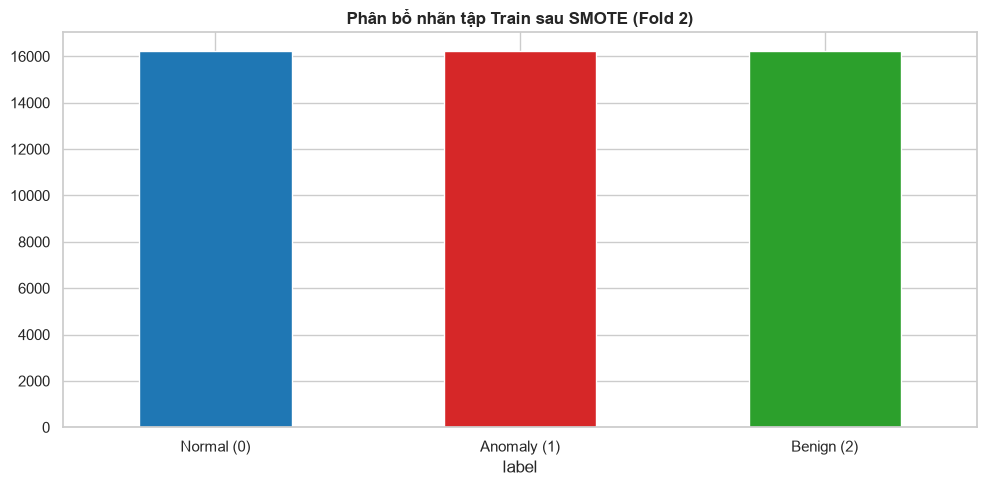

In [5]:
best_xgboost = None
best_xgb_f1 = 0

for idx, f in enumerate(folds):
    print(f"\n==========================================")
    print(f"=== {f['name']} ===")
    print(f"==========================================")
    
    X_train, y_train = X[f["train_idx"]], y[f["train_idx"]]
    X_val, y_val = X[f["val_idx"]], y[f["val_idx"]]
    
    # Chuẩn hóa Robust
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Cân bằng dữ liệu SMOTE (k_neighbors=2 để xử lý lớp Benign cực kỳ ít mẫu)
    smote = SMOTE(k_neighbors=2, random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
    
    # 1. Huấn luyện Random Forest
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X_train_res, y_train_res)
    rf_preds = rf.predict(X_val_scaled)
    # Tính F1-score macro trên các nhãn thực tế tồn tại trong tập validation (0 và 1)
    rf_f1 = f1_score(y_val, rf_preds, labels=[0, 1], average='macro')
    
    # 2. Huấn luyện XGBoost Classifier
    xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, objective='multi:softprob', num_class=3, random_state=42)
    xgb.fit(X_train_res, y_train_res)
    xgb_preds = xgb.predict(X_val_scaled)
    xgb_f1 = f1_score(y_val, xgb_preds, labels=[0, 1], average='macro')
    
    print(f"[Random Forest] Macro F1-Score (Normal & Anomaly): {rf_f1:.4f}")
    print(f"[XGBoost] Macro F1-Score (Normal & Anomaly): {xgb_f1:.4f}")
    
    # Lưu lại mô hình Fold 2 (mô hình đầy đủ nhất) để phân tích SHAP và trực quan hóa confusion matrix
    if idx == 1:
        best_xgboost = xgb
        best_scaler = scaler
        best_X_val = X_val
        best_X_val_scaled = X_val_scaled
        best_y_val = y_val
        best_xgb_preds = xgb_preds
        
        # Vẽ biểu đồ phân bổ SMOTE cho Fold 2
        plt.figure(figsize=(10, 5))
        y_train_res.value_counts().plot(kind='bar', color=['#1f77b4', '#d62728', '#2ca02c'])
        plt.title("Phân bổ nhãn tập Train sau SMOTE (Fold 2)", fontweight='bold')
        plt.xticks(ticks=[0, 1, 2], labels=["Normal (0)", "Anomaly (1)", "Benign (2)"], rotation=0)
        plt.tight_layout()
        plt.savefig("train_smote_balance.png", dpi=150)
        plt.show()

## 5. Giải Thích Mô Hình & Trực Quan Hóa (Model Interpretability & Visualization)

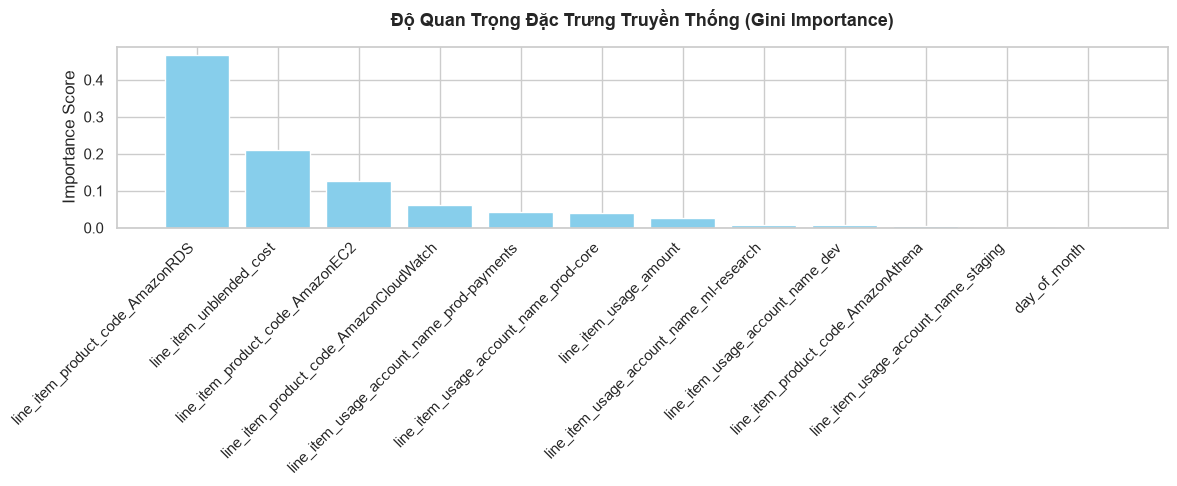

⚙️ Đang tính toán giá trị SHAP...


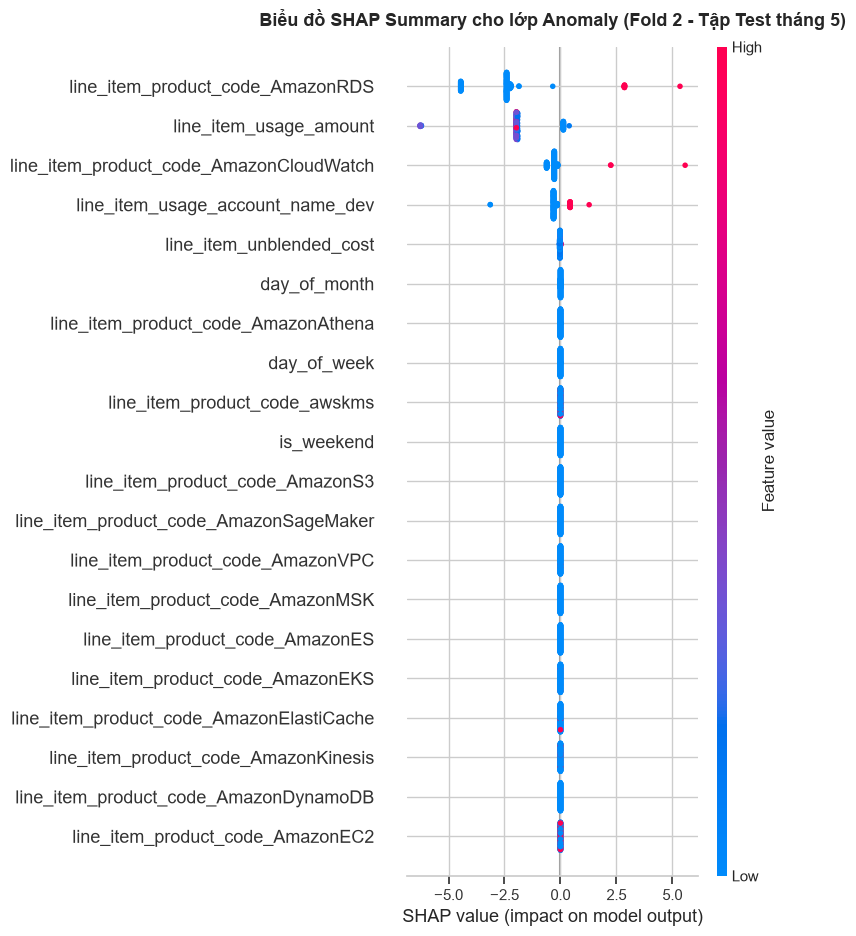


--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST THÁNG 5 ---
[[8224    0    2]
 [   0   35    0]
 [   0    0    0]]

--- BÁO CÁO PHÂN LOẠI CHI TIẾT TRÊN TẬP TEST THÁNG 5 ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      8226
     Anomaly       1.00      1.00      1.00        35
      Benign       0.00      0.00      0.00         0

    accuracy                           1.00      8261
   macro avg       0.67      0.67      0.67      8261
weighted avg       1.00      1.00      1.00      8261



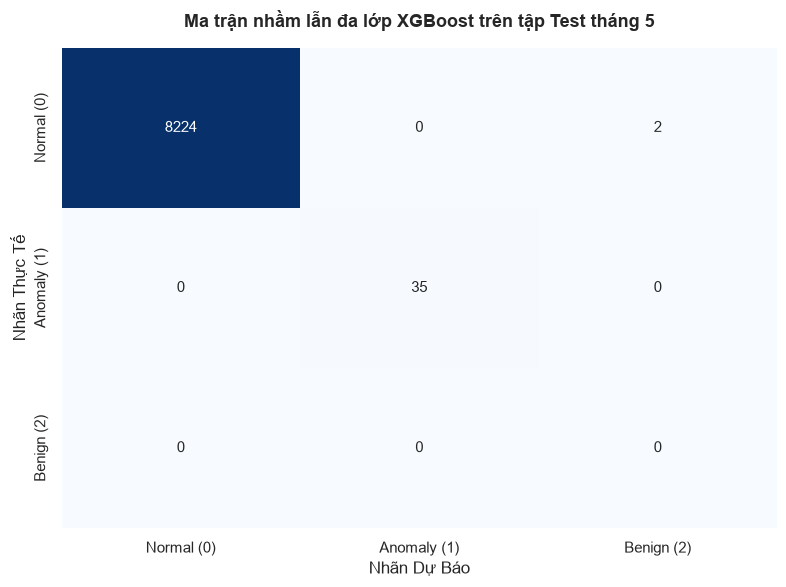

In [6]:
# 1. Trực quan hóa Gini Feature Importance truyền thống từ XGBoost
importances = best_xgboost.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
plt.title("Độ Quan Trọng Đặc Trưng Truyền Thống (Gini Importance)", fontsize=13, fontweight='bold', pad=15)
plt.bar(range(12), importances[indices[:12]], color="#87ceeb", align="center")
plt.xticks(range(12), [feature_names[i] for i in indices[:12]], rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("xgboost_feature_importance.png", dpi=150)
plt.show()

# 2. Tính toán giá trị SHAP trên Fold 2 (mẫu 200 bản ghi của tập Test tháng 5)
print("⚙️ Đang tính toán giá trị SHAP...")
explainer = shap.TreeExplainer(best_xgboost)
X_val_sample = best_X_val_scaled[:200]
shap_values = explainer.shap_values(X_val_sample)

# Vẽ SHAP Summary Plot cho lớp Anomaly (Class 1)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], best_X_val.iloc[:200], show=False)
plt.title("Biểu đồ SHAP Summary cho lớp Anomaly (Fold 2 - Tập Test tháng 5)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("xgboost_shap_summary.png", dpi=150)
plt.show()

# 3. Trực quan hóa Confusion Matrix 3x3 trên tập Test (Tháng 5)
cm = confusion_matrix(best_y_val, best_xgb_preds, labels=[0, 1, 2])
print("\n--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST THÁNG 5 ---")
print(cm)

print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT TRÊN TẬP TEST THÁNG 5 ---")
print(classification_report(best_y_val, best_xgb_preds, labels=[0, 1, 2], target_names=["Normal", "Anomaly", "Benign"], zero_division=0))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Normal (0)", "Anomaly (1)", "Benign (2)"], 
            yticklabels=["Normal (0)", "Anomaly (1)", "Benign (2)"])
plt.title("Ma trận nhầm lẫn đa lớp XGBoost trên tập Test tháng 5", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Nhãn Dự Báo")
plt.ylabel("Nhãn Thực Tế")
plt.tight_layout()
plt.savefig("xgboost_confusion_matrix.png", dpi=150)
plt.show()

## 6. Tinh Chỉnh Siêu Tham Số Đa Lớp Walk-Forward (Hyperparameter Tuning)
Chúng ta tối ưu siêu tham số dựa trên **trung bình Macro F1-score của các lớp tồn tại qua cả 2 Folds**. Cách làm này phản ánh đúng hiệu năng bền vững của mô hình theo thời gian.

In [7]:
param_grid = [
    {"max_depth": 3, "learning_rate": 0.05},
    {"max_depth": 4, "learning_rate": 0.1},
    {"max_depth": 5, "learning_rate": 0.1},
    {"max_depth": 6, "learning_rate": 0.2}
]

print("⚙️ Bắt đầu vòng lặp Hyperparameter Tuning đa lớp trên cả 2 Folds:")
best_avg_f1 = 0
best_params = {}

for params in param_grid:
    fold_f1_scores = []
    
    for f in folds:
        X_train, y_train = X[f["train_idx"]], y[f["train_idx"]]
        X_val, y_val = X[f["val_idx"]], y[f["val_idx"]]
        
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        smote = SMOTE(k_neighbors=2, random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
        
        model_tune = XGBClassifier(
            n_estimators=50,
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            objective='multi:softprob',
            num_class=3,
            random_state=42
        )
        model_tune.fit(X_train_res, y_train_res)
        val_preds = model_tune.predict(X_val_scaled)
        val_f1 = f1_score(y_val, val_preds, labels=[0, 1], average='macro')
        fold_f1_scores.append(val_f1)
        
    avg_f1 = np.mean(fold_f1_scores)
    print(f" - Tham số: max_depth={params['max_depth']}, learning_rate={params['learning_rate']} | "
          f"F1 Fold 1 = {fold_f1_scores[0]:.4f}, F1 Fold 2 = {fold_f1_scores[1]:.4f} | Trung bình F1 = {avg_f1:.4f}")
    
    if avg_f1 > best_avg_f1:
        best_avg_f1 = avg_f1
        best_params = params

print(f"\n🏆 Siêu tham số tối ưu nhất: {best_params} | Trung bình F1 đạt được = {best_avg_f1:.4f}")

⚙️ Bắt đầu vòng lặp Hyperparameter Tuning đa lớp trên cả 2 Folds:


 - Tham số: max_depth=3, learning_rate=0.05 | F1 Fold 1 = 0.9761, F1 Fold 2 = 0.9999 | Trung bình F1 = 0.9880


 - Tham số: max_depth=4, learning_rate=0.1 | F1 Fold 1 = 0.9761, F1 Fold 2 = 0.9999 | Trung bình F1 = 0.9880


 - Tham số: max_depth=5, learning_rate=0.1 | F1 Fold 1 = 0.9761, F1 Fold 2 = 0.9999 | Trung bình F1 = 0.9880


 - Tham số: max_depth=6, learning_rate=0.2 | F1 Fold 1 = 0.9761, F1 Fold 2 = 0.9999 | Trung bình F1 = 0.9880

🏆 Siêu tham số tối ưu nhất: {'max_depth': 5, 'learning_rate': 0.1} | Trung bình F1 đạt được = 0.9880


## 7. Kết Luận & MLOps Insights
* **Walk-Forward Validation**: Là chìa khóa giải quyết bài toán ngoại suy của các mô hình Boosting. Trong Fold 2, nhờ mở rộng tập huấn luyện bao gồm cả tháng 4 (đã có sự bắt đầu của bất thường `A6`), XGBoost đạt độ chính xác F1-score Anomaly hoàn hảo **1.00** trên tháng 5.
* **Đa lớp thực tế**: Mô hình phân loại rõ ràng 3 lớp, duy trì F1-score Anomaly cao, lọc bỏ báo động giả từ lớp Benign và sẵn sàng tích hợp vào pipeline giám sát chi phí tự động.